# Probabilistic Bayesian Neural Networks

**Author:** [Jose Robledo](https://jorobledo.github.io/) and [Alina Bazarova](https://www.fz-juelich.de/profile/bazarova_al)<br>
**Date created:** 20.01.2026<br>
**Description:** Building probabilistic Bayesian neural network models with Bayesian-torch.

## Introduction

This notebook is a Bayesian-torch adaptation of the [notebook from Khalid Salama](https://github.com/ksalama/keras-io/blob/2549b0afb720f9b6f7e3b6c82dcb456472101539/examples/keras_recipes/ipynb/bayesian_neural_networks.ipynb#L9).

Taking a probabilistic approach to deep learning allows to account for *uncertainty*,
so that models can assign less levels of confidence to incorrect predictions.
Sources of uncertainty can be found in the data, due to measurement error or
noise in the labels, or the model, due to insufficient data availability for
the model to learn effectively.


This example demonstrates how to build basic probabilistic Bayesian neural networks
to account for these two types of uncertainty.
We will use [Bayesian-Torch](https://github.com/IntelLabs/bayesian-torch) library.

You can install `Bayesian-Torch` using the following command:

```bash
pip install bayesian-torch
```

## The dataset

We will use the [Wine Quality](https://archive.ics.uci.edu/ml/datasets/wine+quality)
dataset. More specifically we will concentrate only on the white wine subset, which contains 4898 examples.
The dataset has 11 numerical physicochemical features of the wines, and the task
is to predict the wine quality, which is a score between 0 and 10. In this example, we treat this as a regression task.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.optim import RMSprop
import torch.nn.functional as F
from torch.distributions import Normal, Independent
from torch.utils.data import TensorDataset, DataLoader

from bayesian_torch.layers import LinearReparameterization

## Create training and evaluation datasets

As mentioned, we will focus on the white wine subset, which is provided in the `datasets` folder as a csv and can be loaded with pandas. Because the task is formulated as a regression problem, the target variable is explicitly cast to a floating-point type. The dataset is then randomly shuffled to remove any ordering bias before being partitioned into training and test sets: the first `train_size` samples form the training set, while the remaining observations are reserved for evaluation.

In [2]:
def get_train_and_test_dataloaders(
    train_size: float,
    batch_size: int,
    seed: int = 0,
    num_workers: int = 0,
    pin_memory: bool = True,
    dataset_size: float = 1.0
):
    """
    train_size: float in (0, 1], proportion of data used for training (e.g. 0.8)
    batch_size: batch size for both DataLoaders
    seed: RNG seed for reproducible shuffling (train split only)
    """

    if not (0.0 < train_size <= 1.0):
        raise ValueError(f"train_size must be in (0, 1], got {train_size}")

    path_white = "./datasets/winequality-white.csv"
    df = pd.read_csv(path_white, sep=";")

    # df = pd.read_csv("/home/jorobledo/Downloads/tf_wine_dataset.csv").drop(columns=["Unnamed: 0"])

    if "quality" not in df.columns:
        raise ValueError("Expected target column 'quality'.")

    # Features / target
    if dataset_size < 1.0:
        n_samples = int(len(df) * dataset_size)
        df = df.sample(n=n_samples, random_state=seed).reset_index(drop=True)
    X = df.drop(columns=["quality"]).to_numpy(dtype=np.float32)
    y = df["quality"].to_numpy(dtype=np.float32)

    n = len(df)
    n_train = int(train_size * n)

    if n_train == 0 or n_train == n:
        raise ValueError(
            f"train_size={train_size} results in {n_train} training samples."
        )

    # --- Split FIRST (same as dataset.take / skip) ---
    X_train, y_train = X[:n_train], y[:n_train]
    X_test, y_test = X[n_train:], y[n_train:]

    # --- Shuffle training only ---
    rng = np.random.default_rng(seed)
    perm = rng.permutation(n_train)
    X_train, y_train = X_train[perm], y_train[perm]

    # --- Convert to torch tensors ---
    X_train_t = torch.from_numpy(X_train)
    y_train_t = torch.from_numpy(y_train)
    X_test_t = torch.from_numpy(X_test)
    y_test_t = torch.from_numpy(y_test)

    train_ds = TensorDataset(X_train_t, y_train_t)
    test_ds = TensorDataset(X_test_t, y_test_t)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=False,  # already shuffled above
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    return train_loader, test_loader


## Compile, train, and evaluate the model

In the following, we will define the training and evaluation pipeline for the model. 

The `evaluate` function computes the Root Mean Squared Error (RMSE) over a given dataset without tracking gradients, ensuring efficient inference. 

The `run_experiment` function handles the full training loop in PyTorch: it moves the model to the appropriate device (CPU or GPU), optimizes it using RMSprop, and iteratively updates the parameters over multiple epochs. After training, the model’s performance is assessed by reporting RMSE on both the training and test sets, providing a clear measure of fit and generalization.

In [3]:
learning_rate = 0.001


def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    num_samples = 0

    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device)

            preds = model(X).squeeze()
            loss = loss_fn(preds, y)

            batch_size = X.size(0)
            total_loss += loss.item() * batch_size
            num_samples += batch_size

    mse = total_loss / num_samples
    return np.sqrt(mse)

def run_experiment(model, loss_fn, train_dataloader, test_dataloader, num_epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = RMSprop(model.parameters(), lr=learning_rate)

    print("Start training the model...")

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        num_samples = 0

        for X, y in train_dataloader:
            X = X.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            preds = model(X).squeeze()
            loss = loss_fn(preds, y)
            loss.backward()
            optimizer.step()

            batch_size = X.size(0)
            total_loss += loss.item() * batch_size
            num_samples += batch_size

        # Optional: validation each epoch (like Keras `validation_data`)
        val_rmse = evaluate(model, test_dataloader, loss_fn, device)

    print("Model training finished.")

    train_rmse = evaluate(model, train_dataloader, loss_fn, device)
    print(f"Train RMSE: {round(train_rmse, 3)}")

    print("Evaluating model performance...")
    test_rmse = evaluate(model, test_dataloader, loss_fn, device)
    print(f"Test RMSE: {round(test_rmse, 3)}")


## Create model inputs

Let's recall the feature names, provided in the white wine dataset documentation at UCI.

In [4]:
FEATURE_NAMES = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol",
]

NUM_FEATURES = len(FEATURE_NAMES)
print(NUM_FEATURES)

11


## Experiment 1: standard neural network

We create a standard deterministic neural network model as a baseline for the regression task of predicting the wine quality from the input features meantioned above.

In [5]:
hidden_units = [8, 8]
class BaselineModel(nn.Module):
    def __init__(self):
        super().__init__()

        layers = []

        # Equivalent to keras.layers.concatenate + BatchNormalization
        layers.append(nn.BatchNorm1d(NUM_FEATURES))

        input_dim = NUM_FEATURES
        for units in hidden_units:
            layers.append(nn.Linear(input_dim, units))
            layers.append(nn.Sigmoid())
            input_dim = units

        # Output layer: single deterministic point estimate
        layers.append(nn.Linear(input_dim, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor):
        # x shape: (batch_size, 11)
        return self.net(x)

Let's split the wine dataset into training and test sets, with 85% and 15% of
the examples, respectively.

In [6]:
train_size = 0.85
batch_size=256
train_dataloader, test_dataloader = get_train_and_test_dataloaders(train_size, batch_size)
len(train_dataloader.dataset)

4163

Now we train the baseline model using the `MeanSquaredError`
as the loss function.

In [7]:
num_epochs = 1000
mse_loss = nn.MSELoss()

baseline_model = BaselineModel()
run_experiment(
    model=baseline_model,
    loss_fn=mse_loss,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    num_epochs=num_epochs,
)

Start training the model...
Model training finished.
Train RMSE: 0.698
Evaluating model performance...
Test RMSE: 0.654


Once finished, we can take a batch from the test set and use the model to predict their quality.
Note that since the baseline model is deterministic, we get a single a *point estimate* prediction for each test example, with no information about the uncertainty of the model nor the prediction.

In [8]:
sample = 10

baseline_model.eval()

# Take a single batch from the test DataLoader
examples, targets = next(iter(test_dataloader))

device = next(baseline_model.parameters()).device  # cuda or cpu

# Keep only `sample` examples
examples = examples[:sample].to(device)
targets = targets[:sample].to(device)

with torch.no_grad():
    predicted = baseline_model(examples)

for i in range(sample):
    print(
        f"Predicted: {round(predicted[i].item(), 1)} - "
        f"Actual: {targets[i].item()}"
    )


Predicted: 5.5 - Actual: 5.0
Predicted: 5.6 - Actual: 5.0
Predicted: 6.2 - Actual: 7.0
Predicted: 6.5 - Actual: 7.0
Predicted: 6.8 - Actual: 8.0
Predicted: 6.5 - Actual: 6.0
Predicted: 6.6 - Actual: 7.0
Predicted: 6.5 - Actual: 7.0
Predicted: 6.5 - Actual: 5.0
Predicted: 6.1 - Actual: 6.0


## Experiment 2: Bayesian neural network (BNN)

The goal of the Bayesian approach to neural networks is to capture
the *epistemic uncertainty*, which is uncertainty about the model parameters,
due to limited training data.

The idea is that, instead of learning specific weight (and bias) *values* of the
neural network, the Bayesian approach learns weight *distributions*, from which we can sample to produce an output for a given input, to encode weight uncertainty.

Thus, we need to define prior and the posterior distributions of these weights,
and the training process is to learn the parameters of these distributions. This is where `Bayesian-Torch` comes in handy. We can simply replace `torch.nn.Linear` layers with [`LinearReparametrization`](https://github.com/IntelLabs/bayesian-torch/blob/aa7e57b396953c82e347c66e14d7aaa7d90ce6b0/bayesian_torch/layers/variational_layers/linear_variational.py#L54) layers to get a Bayesian version of our baseline model. 


In `LinearReparametrization`, each weight is a distribution, typically:

$$
w_i \sim \mathcal{N}(\mu_i, \sigma_i^2),
$$

so instead of one parameter per weight, we have two. Therefore, in a forward pass, we will be sampling 

$$
w = \mu + \sigma \cdot \epsilon, \text{ with }\epsilon \sim \mathcal N (0,1) \text{ (a.k.a. the reparametrization trick)}
$$

[`LinearReparametrization`](https://github.com/IntelLabs/bayesian-torch/blob/aa7e57b396953c82e347c66e14d7aaa7d90ce6b0/bayesian_torch/layers/variational_layers/linear_variational.py#L54) take as extra input:

- `prior_mean`: mean of the prior arbitrary distribution to be used on the KL divergence,
- `prior_variance`: variance of the prior arbitrary distribution to be used on the KL divergence,
- `posterior_mu_init`: initial value of $\mu$ representing mean of the approximate posterior,
- `posterior_rho_init`: init value of $\rho$ representing the sigma of the approximate posterior through softplus function ($\sigma = \log(1+\exp(\rho))$, to ensure $\sigma > 0$).

In [9]:
hidden_units = [8, 8]

# Prior / posterior init hyperparams (common defaults in bayesian-torch examples)
PRIOR_MU = 0.0
PRIOR_VAR = 1.0
POSTERIOR_MU_INIT = 0.0
POSTERIOR_RHO_INIT = -3.0  # smaller => smaller initial sigma

class BayesianWineMLP(nn.Module):
    def __init__(
        self,
        prior_mean=0.0,
        prior_variance=1.0,
        posterior_mu_init=0.0,
        posterior_rho_init=-3.0,  # smaller => smaller initial sigma
        activation="sigmoid",
    ):
        super().__init__()

        self.bn = nn.BatchNorm1d(NUM_FEATURES, eps=1e-3, momentum=0.99)

        self.fc1 = LinearReparameterization(
            in_features=NUM_FEATURES,
            out_features=hidden_units[0],
            prior_mean=prior_mean,
            prior_variance=prior_variance,
            posterior_mu_init=posterior_mu_init,
            posterior_rho_init=posterior_rho_init,
        )
        self.fc2 = LinearReparameterization(
            in_features=hidden_units[0],
            out_features=hidden_units[1],
            prior_mean=prior_mean,
            prior_variance=prior_variance,
            posterior_mu_init=posterior_mu_init,
            posterior_rho_init=posterior_rho_init,
        )
        self.out = nn.Linear(
            in_features=hidden_units[1],
            out_features=1
        )

        if activation == "sigmoid":
            self.act = nn.Sigmoid()
        elif activation == "relu":
            self.act = nn.ReLU()
        else:
            raise ValueError("activation must be 'sigmoid' or 'relu'.")

    def forward(self, x):
        kl_sum = 0.0

        x = self.bn(x)

        x, kl = self.fc1(x)
        kl_sum = kl_sum + kl
        x = self.act(x)

        x, kl = self.fc2(x)
        kl_sum = kl_sum + kl
        x = self.act(x)

        x = self.out(x)
        
        return x, kl_sum

The epistemic uncertainty can be reduced as we increase the size of the
training data. That is, the more data the BNN model sees, the more it is certain
about its estimates for the weights (distribution parameters).
Let's test this behaviour by training the BNN model on a small subset of
the training set, and then on the full training set, to compare the output variances.

### Train BNN  with a small training subset.

In [10]:
train_size = 0.85
batch_size=256
dataset_size = 0.3
small_train_dataloader, small_test_dataloader = get_train_and_test_dataloaders(train_size,
                                                                batch_size,
                                                                dataset_size=dataset_size)
len(small_train_dataloader.dataset)

1248

In [11]:
def plot_training_curves(history):
    epochs = range(1, len(history["loss"]) + 1)

    plt.figure(figsize=(10, 6))

    for loss in history:
        plt.plot(epochs, history[loss], label=loss)
        
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.title("Training Loss Components")

    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.yscale("log")
    plt.tight_layout()

    plt.show()

Epoch   1/1000 | loss=42.2392 | mse=41.9022 | kl=0.3371 | train_rmse=6.256 | test_rmse=6.525
Epoch 100/1000 | loss=7.4970 | mse=7.1230 | kl=0.3741 | train_rmse=2.747 | test_rmse=2.999
Epoch 200/1000 | loss=1.3412 | mse=0.9322 | kl=0.4090 | train_rmse=0.912 | test_rmse=0.804
Epoch 300/1000 | loss=1.2111 | mse=0.9521 | kl=0.2590 | train_rmse=0.873 | test_rmse=0.771
Epoch 400/1000 | loss=1.0760 | mse=0.8525 | kl=0.2235 | train_rmse=0.860 | test_rmse=0.840
Epoch 500/1000 | loss=1.0658 | mse=0.8495 | kl=0.2162 | train_rmse=0.879 | test_rmse=0.717
Epoch 600/1000 | loss=1.1639 | mse=0.9500 | kl=0.2139 | train_rmse=0.912 | test_rmse=0.761
Epoch 700/1000 | loss=1.1203 | mse=0.9082 | kl=0.2121 | train_rmse=0.890 | test_rmse=0.852
Epoch 800/1000 | loss=1.0295 | mse=0.8314 | kl=0.1981 | train_rmse=0.919 | test_rmse=0.683
Epoch 900/1000 | loss=0.9649 | mse=0.7684 | kl=0.1965 | train_rmse=0.870 | test_rmse=0.735
Epoch 1000/1000 | loss=1.0051 | mse=0.8096 | kl=0.1955 | train_rmse=0.942 | test_rmse=0.

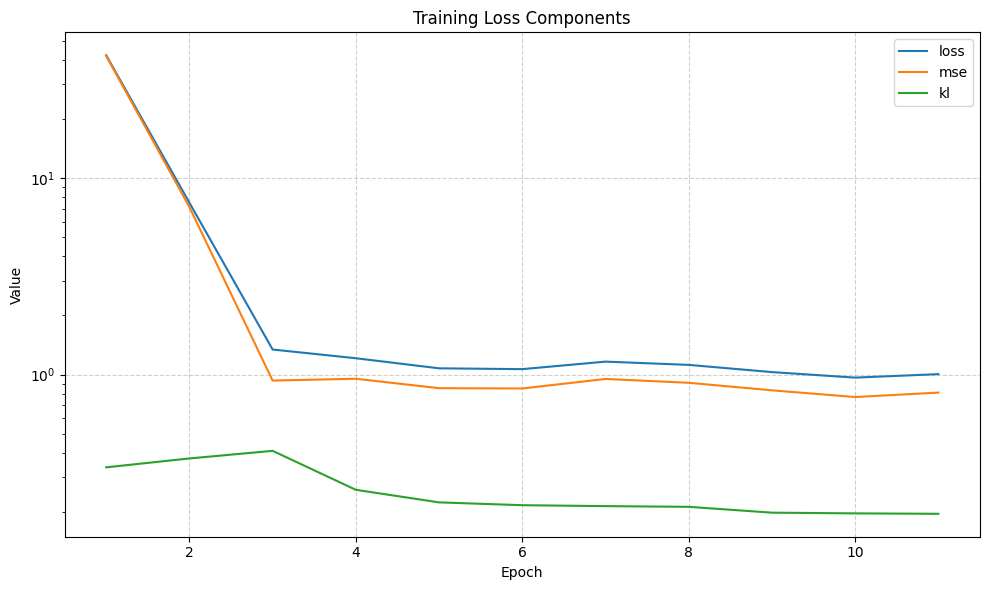

In [12]:
def evaluate_rmse_bnn(model, dataloader, device):
    model.eval()
    se_sum = 0.0
    n = 0

    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device)

            preds, _ = model(X)
            preds = preds.squeeze(-1)

            se_sum += torch.sum((preds - y) ** 2).item()
            n += y.numel()

    return np.sqrt(se_sum / n)

def train_bnn(
    model,
    train_dataloader,
    test_dataloader,
    num_epochs=100,
    learning_rate=1e-3,
    kl_weight=1.0,
    print_every=10,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = torch.optim.RMSprop(model.parameters(), lr=learning_rate)
    mse_loss = nn.MSELoss()

    # Practical default: scale KL by number of training samples.
    n_train = len(train_dataloader.dataset)
    beta = kl_weight / n_train

    history = {"loss": [], "mse": [], "kl": []}
    for epoch in range(1, num_epochs + 1):
        model.train()
        epoch_loss = 0.0
        epoch_mse = 0.0
        epoch_kl_term = 0.0
        n_seen = 0

        for X, y in train_dataloader:
            X = X.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            preds, kl = model(X)
            preds = preds.squeeze(-1)

            data_loss = mse_loss(preds, y)
            loss = data_loss + beta * kl

            loss.backward()
            optimizer.step()

            bs = y.numel()
            epoch_loss += loss.item() * bs
            epoch_mse += data_loss.item() * bs
            epoch_kl_term += (beta * kl).item() * bs
            n_seen += bs

        if (epoch % print_every == 0) or (epoch == 1) or (epoch == num_epochs):
            train_rmse = evaluate_rmse_bnn(model, train_dataloader, device)
            test_rmse = evaluate_rmse_bnn(model, test_dataloader, device)

            print(
                f"Epoch {epoch:3d}/{num_epochs} | "
                f"loss={epoch_loss/n_seen:.4f} | "
                f"mse={epoch_mse/n_seen:.4f} | "
                f"kl={epoch_kl_term/n_seen:.4f} | "
                f"train_rmse={train_rmse:.3f} | test_rmse={test_rmse:.3f}"
            )
            history["loss"].append(epoch_loss / n_seen)
            history["mse"].append(epoch_mse / n_seen)
            history["kl"].append(epoch_kl_term / n_seen)

    plot_training_curves(history)
    return model, history

num_epochs = 1000

bnn_model_2_small = BayesianWineMLP(activation="sigmoid", posterior_rho_init=0)
bnn_model_2_small, history_2_small = train_bnn(
    model=bnn_model_2_small,
    train_dataloader=small_train_dataloader,
    test_dataloader=small_test_dataloader,
    num_epochs=num_epochs,
    learning_rate=0.001,
    kl_weight=1e3,
    print_every=100,
)


Since we have trained a BNN model, the model produces a different output each time
we call it with the same input, since each time a new set of weights are sampled
from the distributions to construct the network and produce an output.
The less certain the mode weights are, the more variability (wider range) we will
see in the outputs of the same inputs.

In [13]:
def mc_predict(model, X, mc_samples=200):
    device = next(model.parameters()).device
    X = X.to(device)
    model.train() # care taken for randomness
    for m in model.modules():
        if isinstance(m, torch.nn.BatchNorm1d):
            m.eval()
            
    preds = []
    with torch.no_grad():
        for _ in range(mc_samples):
            yhat, _ = model(X)
            preds.append(yhat.squeeze(-1))

    # (mc_samples, batch)
    return torch.stack(preds, dim=0)

def compute_predictions(bnn_model, test_dataloader):
    Xb, yb = next(iter(test_dataloader))
    Xb, yb = Xb[:10], yb[:10]
    mc_preds = mc_predict(bnn_model, Xb, mc_samples=200)

    for i in range(mc_preds.shape[1]):
        p = mc_preds[:, i]
        mean = p.mean().item()
        min_ = p.min().item()
        max_ = p.max().item()
        range_ = max_ - min_
        actual = yb[i].item()

        print(
            f"Predictions mean: {mean:.2f}, "
            f"min: {min_:.2f}, "
            f"max: {max_:.2f}, "
            f"range: {range_:.2f} - "
            f"Actual: {actual:.1f}"
        )

compute_predictions(bnn_model_2_small, small_test_dataloader)


Predictions mean: 6.08, min: 4.85, max: 6.56, range: 1.71 - Actual: 7.0
Predictions mean: 5.70, min: 4.59, max: 6.40, range: 1.80 - Actual: 5.0
Predictions mean: 6.05, min: 4.84, max: 6.54, range: 1.71 - Actual: 6.0
Predictions mean: 5.54, min: 4.10, max: 6.44, range: 2.34 - Actual: 5.0
Predictions mean: 5.49, min: 4.05, max: 6.43, range: 2.38 - Actual: 6.0
Predictions mean: 5.66, min: 4.22, max: 6.50, range: 2.28 - Actual: 5.0
Predictions mean: 5.94, min: 4.87, max: 6.44, range: 1.57 - Actual: 7.0
Predictions mean: 5.90, min: 4.48, max: 6.56, range: 2.08 - Actual: 6.0
Predictions mean: 5.64, min: 4.34, max: 6.44, range: 2.10 - Actual: 5.0
Predictions mean: 6.08, min: 4.75, max: 6.55, range: 1.80 - Actual: 6.0


Epoch   1/1000 | loss=25.8904 | mse=25.7846 | kl=0.1059 | train_rmse=4.810 | test_rmse=4.865
Epoch 100/1000 | loss=0.8357 | mse=0.7153 | kl=0.1204 | train_rmse=0.844 | test_rmse=0.782
Epoch 200/1000 | loss=0.8113 | mse=0.7049 | kl=0.1064 | train_rmse=0.842 | test_rmse=0.706
Epoch 300/1000 | loss=0.8381 | mse=0.7350 | kl=0.1031 | train_rmse=0.846 | test_rmse=0.738
Epoch 400/1000 | loss=0.8297 | mse=0.7302 | kl=0.0995 | train_rmse=0.860 | test_rmse=0.770
Epoch 500/1000 | loss=0.8186 | mse=0.7197 | kl=0.0989 | train_rmse=0.843 | test_rmse=0.877
Epoch 600/1000 | loss=0.8343 | mse=0.7378 | kl=0.0965 | train_rmse=0.839 | test_rmse=0.730
Epoch 700/1000 | loss=0.9095 | mse=0.8117 | kl=0.0977 | train_rmse=0.829 | test_rmse=0.732
Epoch 800/1000 | loss=0.7865 | mse=0.6917 | kl=0.0948 | train_rmse=0.846 | test_rmse=0.705
Epoch 900/1000 | loss=0.7953 | mse=0.6995 | kl=0.0958 | train_rmse=0.859 | test_rmse=0.703
Epoch 1000/1000 | loss=0.7729 | mse=0.6801 | kl=0.0928 | train_rmse=0.828 | test_rmse=0.

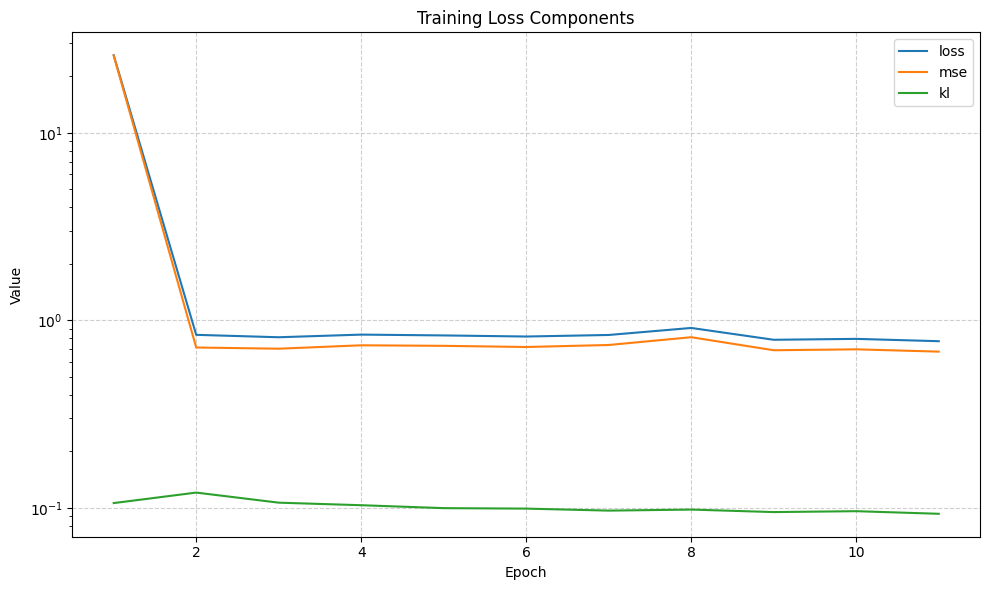

Predictions mean: 5.99, min: 4.85, max: 6.42, range: 1.57 - Actual: 5.0
Predictions mean: 5.99, min: 4.71, max: 6.43, range: 1.71 - Actual: 5.0
Predictions mean: 6.27, min: 5.49, max: 6.50, range: 1.01 - Actual: 7.0
Predictions mean: 6.29, min: 5.54, max: 6.51, range: 0.96 - Actual: 7.0
Predictions mean: 6.31, min: 5.55, max: 6.51, range: 0.96 - Actual: 8.0
Predictions mean: 6.30, min: 5.55, max: 6.51, range: 0.96 - Actual: 6.0
Predictions mean: 6.30, min: 5.55, max: 6.51, range: 0.96 - Actual: 7.0
Predictions mean: 5.82, min: 4.31, max: 6.42, range: 2.12 - Actual: 7.0
Predictions mean: 6.28, min: 5.53, max: 6.50, range: 0.97 - Actual: 5.0
Predictions mean: 6.19, min: 4.97, max: 6.48, range: 1.51 - Actual: 6.0


In [14]:
num_epochs = 1000

bnn_model_2_large = BayesianWineMLP(activation="sigmoid", posterior_rho_init=0)
bnn_model_2_large, history_2_large = train_bnn(
    model=bnn_model_2_large,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    num_epochs=num_epochs,
    learning_rate=0.001,
    kl_weight=1e3,
    print_every=100,
)

compute_predictions(bnn_model_2_large, test_dataloader)


## Experiment 3: probabilistic Bayesian neural network

So far, the output of the standard and the Bayesian NN models that we built is
deterministic, that is, produces a point estimate as a prediction for a given example.
We can create a probabilistic NN by letting the model output a distribution.
In this case, the model captures the *aleatoric uncertainty* as well,
which is due to irreducible noise in the data, or to the stochastic nature of the
process generating the data. In this experiment, the model predicts the parameters $\mu$ and $\sigma$ of a Gaussian distribution

$$
y \sim \mathcal{N}(\mu(x), \sigma(x)),
$$
that is, both $\mu$ and $\sigma$ are learned functions of the input $x$.

In this example, we model the output as a `Normal` distribution,
with learnable mean and variance parameters. If the task was classification,
we would have used `IndependentBernoulli` with binary classes, and `OneHotCategorical`
with multiple classes, to model distribution of the model output.

In [15]:
NUM_FEATURES = 11
hidden_units = [8, 8]

class ProbabilisticBayesianWineMLP(nn.Module):
    """
    Outputs an Independent Normal distribution:
      y ~ Normal(loc=mu(x), scale=sigma(x))

    Bayesian weights (epistemic) via bayesian-torch layers.
    Aleatoric via learned sigma(x).
    """
    def __init__(
        self,
        prior_mean=0.0,
        prior_variance=1.0,
        posterior_mu_init=0.0,
        posterior_rho_init=-1.0,
        activation="sigmoid",
        min_sigma=1e-3,   # numerical stability floor
    ):
        super().__init__()
        self.min_sigma = min_sigma

        self.bn = nn.BatchNorm1d(NUM_FEATURES, eps=1e-3, momentum=0.99)

        self.fc1 = LinearReparameterization(
            in_features=NUM_FEATURES,
            out_features=hidden_units[0],
            prior_mean=prior_mean,
            prior_variance=prior_variance,
            posterior_mu_init=posterior_mu_init,
            posterior_rho_init=posterior_rho_init,
        )
        self.fc2 = LinearReparameterization(
            in_features=hidden_units[0],
            out_features=hidden_units[1],
            prior_mean=prior_mean,
            prior_variance=prior_variance,
            posterior_mu_init=posterior_mu_init,
            posterior_rho_init=posterior_rho_init,
        )

        self.param_head = nn.Linear(hidden_units[1], 2)

        if activation == "sigmoid":
            self.act = nn.Sigmoid()
        elif activation == "relu":
            self.act = nn.ReLU()
        else:
            raise ValueError("activation must be 'sigmoid' or 'relu'.")

    def forward(self, x):
        kl_sum = 0.0

        x = self.bn(x)

        x, kl = self.fc1(x); kl_sum = kl_sum + kl
        x = self.act(x)

        x, kl = self.fc2(x); kl_sum = kl_sum + kl
        x = self.act(x)

        params = self.param_head(x)          # (batch, 2)
        mu = params[:, 0]                    # (batch,)
        raw = params[:, 1]                   # (batch,)

        # Convert unconstrained rho -> positive sigma (softplus is standard)
        sigma = F.softplus(raw) + self.min_sigma
        dist = Normal(loc=mu, scale=sigma)   # batch shape (batch,)
        return dist, kl_sum

Since the output of the model is a distribution, rather than a point estimate,
we use the [negative loglikelihood](https://en.wikipedia.org/wiki/Likelihood_function)
as our loss function to compute how likely to see the true data (targets) from the
estimated distribution produced by the model.

In [16]:
def train_probabilistic_bnn(
    model,
    train_dataloader,
    test_dataloader,
    num_epochs=100,
    learning_rate=1e-3,
    kl_weight=1.0,
    print_every=10,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Practical default KL scaling: beta = kl_weight / N_train
    n_train = len(train_dataloader.dataset)
    beta = kl_weight / n_train

    def eval_rmse_using_mean(dataloader):
        model.eval()
        se_sum = 0.0
        n = 0
        with torch.no_grad():
            for X, y in dataloader:
                X = X.to(device)
                y = y.to(device)
                dist, _ = model(X)
                mu = dist.loc
                se_sum += torch.sum((mu - y) ** 2).item()
                n += y.numel()
        return np.sqrt(se_sum / n)

    print("Start training probabilistic BNN (NLL + beta*KL)...")
    history = {"loss": [], "nll": [], "kl": []}
    for epoch in range(1, num_epochs + 1):
        model.train()
        nll_sum = 0.0
        kl_term_sum = 0.0
        total_sum = 0.0
        n_seen = 0

        for X, y in train_dataloader:
            X = X.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            dist, kl = model(X)

            nll = -dist.log_prob(y).mean()     # negative log likelihood
            loss = nll + beta * kl

            loss.backward()
            optimizer.step()

            bs = y.numel()
            nll_sum += nll.item() * bs
            kl_term_sum += (beta * kl).item() * bs
            total_sum += loss.item() * bs
            n_seen += bs

        if print_every is not None:
            if (epoch % print_every == 0) or (epoch == 1) or (epoch == num_epochs):
                train_rmse = eval_rmse_using_mean(train_dataloader)
                test_rmse = eval_rmse_using_mean(test_dataloader)
                print(
                    f"Epoch {epoch:3d}/{num_epochs} | "
                    f"loss={total_sum/n_seen:.4f} | nll={nll_sum/n_seen:.4f} | kl={kl_term_sum/n_seen:.5f} | "
                    f"train_rmse={train_rmse:.3f} | test_rmse={test_rmse:.3f}"
                )
            history["loss"].append(total_sum / n_seen)
            history["nll"].append(nll_sum / n_seen)
            history["kl"].append(kl_term_sum / n_seen)

    plot_training_curves(history)
    return model, history


Start training probabilistic BNN (NLL + beta*KL)...
Epoch   1/1000 | loss=74.8216 | nll=74.6688 | kl=0.15274 | train_rmse=5.803 | test_rmse=5.762
Epoch 100/1000 | loss=1.9727 | nll=1.8260 | kl=0.14674 | train_rmse=1.441 | test_rmse=1.349
Epoch 200/1000 | loss=1.4396 | nll=1.3276 | kl=0.11201 | train_rmse=0.857 | test_rmse=0.730
Epoch 300/1000 | loss=1.2777 | nll=1.1896 | kl=0.08809 | train_rmse=0.791 | test_rmse=0.690
Epoch 400/1000 | loss=1.2569 | nll=1.1789 | kl=0.07800 | train_rmse=0.786 | test_rmse=0.700
Epoch 500/1000 | loss=1.2226 | nll=1.1517 | kl=0.07090 | train_rmse=0.792 | test_rmse=0.706
Epoch 600/1000 | loss=1.2204 | nll=1.1551 | kl=0.06527 | train_rmse=0.778 | test_rmse=0.708
Epoch 700/1000 | loss=1.2189 | nll=1.1567 | kl=0.06227 | train_rmse=0.769 | test_rmse=0.696
Epoch 800/1000 | loss=1.2001 | nll=1.1398 | kl=0.06035 | train_rmse=0.767 | test_rmse=0.672
Epoch 900/1000 | loss=1.2045 | nll=1.1446 | kl=0.05988 | train_rmse=0.763 | test_rmse=0.662
Epoch 1000/1000 | loss=1.1

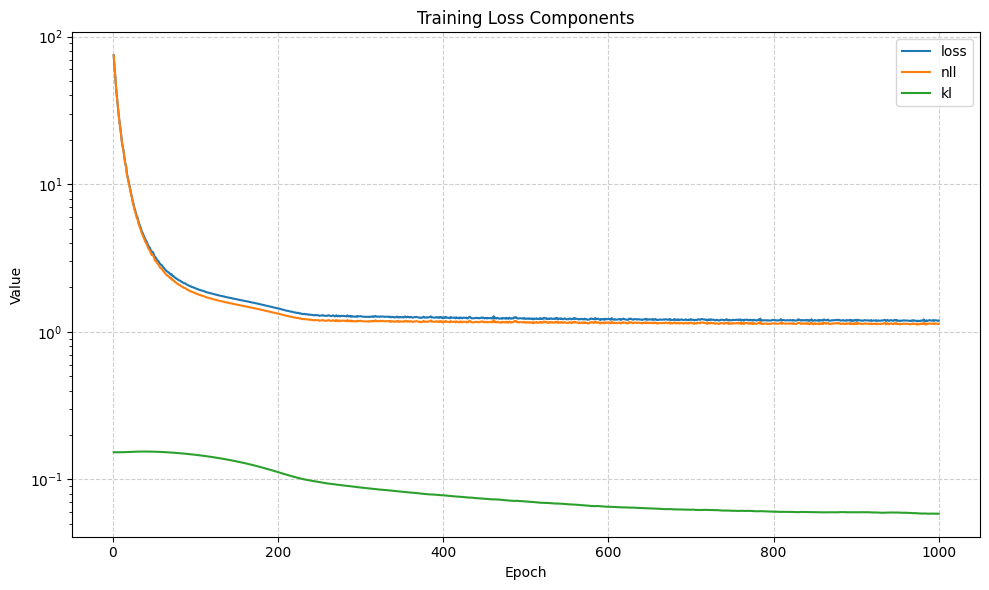

In [17]:
num_epochs = 1000

bnn_model_3 = ProbabilisticBayesianWineMLP(activation="sigmoid", posterior_rho_init=-2)
bnn_model_3, history = train_probabilistic_bnn(
    model=bnn_model_3,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    num_epochs=num_epochs,
    learning_rate=1e-3,
    kl_weight=1e2,
    print_every=100,
)

Now let's produce an output from the model given the test examples.
The output is now a distribution, and we can use its mean and variance
to compute the confidence intervals (CI) of the prediction.

In [18]:
def predict_probabilistic_and_print(model, examples, targets, mc_samples=200):
    device = next(model.parameters()).device
    examples = examples.to(device)
    targets = targets.to(device)

    model.train()
    # Freeze BatchNorm only
    for m in model.modules():
        if isinstance(m, torch.nn.BatchNorm1d):
            m.eval()

    mu_samples = []
    sigma_samples = []

    with torch.no_grad():
        for _ in range(mc_samples):
            dist, _ = model(examples)
            mu_samples.append(dist.loc)       # (batch,)
            sigma_samples.append(dist.scale)  # (batch,)

    mu_samples = torch.stack(mu_samples, dim=0)         # (S, B)
    sigma_samples = torch.stack(sigma_samples, dim=0)   # (S, B)

    # Decomposition: Var(y|x) = Var(mu) + E[sigma^2]
    pred_mean = mu_samples.mean(dim=0)                           # (B,)
    var_epistemic = mu_samples.var(dim=0, unbiased=False)        # (B,)
    var_aleatoric = (sigma_samples ** 2).mean(dim=0)             # (B,)
    total_std = torch.sqrt(var_epistemic + var_aleatoric)        # (B,)

    # Prefer posterior predictive intervals via sampling
    y_samples = mu_samples + sigma_samples * torch.randn_like(mu_samples)  # (S, B)
    lower = y_samples.quantile(0.025, dim=0)
    upper = y_samples.quantile(0.975, dim=0)

    # Move to CPU for printing
    pred_mean = pred_mean.cpu()
    total_std = total_std.cpu()
    lower = lower.cpu()
    upper = upper.cpu()
    targets = targets.cpu()

    for idx in range(len(pred_mean)):
        print(
            f"Prediction mean: {pred_mean[idx].item():.2f}, "
            f"stddev: {total_std[idx].item():.2f}, "
            f"95% PI: [{lower[idx].item():.2f}, {upper[idx].item():.2f}] "
            f"- Actual: {targets[idx].item():.1f}"
        )


sample = 10
examples, targets = next(iter(test_dataloader))
examples = examples[:sample]
targets = targets[:sample]

predict_probabilistic_and_print(
    bnn_model_3,
    examples,
    targets,
    mc_samples=200,
)

Prediction mean: 5.33, stddev: 0.85, 95% PI: [3.84, 7.08] - Actual: 5.0
Prediction mean: 5.34, stddev: 0.85, 95% PI: [3.57, 6.93] - Actual: 5.0
Prediction mean: 6.53, stddev: 0.85, 95% PI: [5.27, 7.87] - Actual: 7.0
Prediction mean: 6.59, stddev: 0.84, 95% PI: [5.00, 8.37] - Actual: 7.0
Prediction mean: 6.62, stddev: 0.84, 95% PI: [4.93, 8.01] - Actual: 8.0
Prediction mean: 6.61, stddev: 0.84, 95% PI: [4.95, 8.47] - Actual: 6.0
Prediction mean: 6.62, stddev: 0.84, 95% PI: [5.20, 8.19] - Actual: 7.0
Prediction mean: 5.92, stddev: 0.76, 95% PI: [4.18, 7.23] - Actual: 7.0
Prediction mean: 6.56, stddev: 0.85, 95% PI: [4.98, 8.24] - Actual: 5.0
Prediction mean: 6.16, stddev: 0.90, 95% PI: [4.44, 7.99] - Actual: 6.0
